In [1]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

import pandas as pd
import networkx as nx
import numpy as np

from src import data_utils

df = data_utils.read_dataframe("datasets/SOCRATES_v1.csv")
data = torch.load('hidden_repr/SOCRATES_v1_Mistral-Large-Instruct-2407_embeddings.pt')

/u/kdkyum/conda-envs/reasoning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df[["e1.wikidata_qid", "r1.category", "e2.wikidata_qid", "r2.category", "e3.wikidata_qid"]]

,e1.wikidata_qid,r1.category,e2.wikidata_qid,r2.category,e3.wikidata_qid
0,Q495,eurovisioncity-year,2022,year-nobelchem,Q6914509
1,Q33720571,g7city-year,2017,year-nobelchem,Q28833112
2,Q5529960,person-country,Q30,country-anthem,Q44696
3,Q3218144,person-country,Q30,country-anthem,Q44696
4,Q17275467,person-country,Q30,country-anthem,Q44696
...,...,...,...,...,...
7227,Q11904736,person-city,Q648,city-capitalofcultureyear,2004
7228,Q89393,person-city,Q13972,city-capitalofcultureyear,2024
7229,Q2433666,person-city,Q1726,city-eurovisionyear,1983
7230,Q109459,person-city,Q1726,city-eurovisionyear,1983


In [3]:
qid_to_value = {}
for _, row in df.iterrows():
    qid_to_value[row['e1.wikidata_qid']] = row['e1.value']
    qid_to_value[row['e2.wikidata_qid']] = row['e2.value']
    qid_to_value[row['e3.wikidata_qid']] = row['e3.value']

In [4]:
if '' in qid_to_value:
    del qid_to_value['']

In [5]:
# 1. Build a global entity → index mapping
entity_set = (
    set(df["e1.wikidata_qid"])
    | set(df["e2.wikidata_qid"])
    | set(df["e3.wikidata_qid"])
)
entity_set.discard('')

entity2idx = {qid: i for i, qid in enumerate(sorted(entity_set))}
idx2entity = {idx: k for k, idx in entity2idx.items()}
num_entities = len(entity2idx)

# 2. Collect all (head, relation, tail) triples
triples1 = df[["e1.wikidata_qid", "r1.category", "e2.wikidata_qid"]].copy()
triples1.columns = ["head", "rel", "tail"]

# Replace empty strings with corresponding values
empty_head_mask = triples1["head"] == ''
empty_tail_mask = triples1["tail"] == ''

triples1.loc[empty_head_mask, "head"] = df.loc[empty_head_mask, "e1.value"].values
triples1.loc[empty_tail_mask, "tail"] = df.loc[empty_tail_mask, "e2.value"].values

triples2 = df[["e2.wikidata_qid", "r2.category", "e3.wikidata_qid"]].copy()
triples2.columns = ["head", "rel", "tail"]

# Replace empty strings with corresponding values
empty_head_mask = triples2["head"] == ''
empty_tail_mask = triples2["tail"] == ''

triples2.loc[empty_head_mask, "head"] = df.loc[empty_head_mask, "e2.value"].values
triples2.loc[empty_tail_mask, "tail"] = df.loc[empty_tail_mask, "e3.value"].values
all_triples = pd.concat([triples1, triples2], ignore_index=True)

# 3. Build one sparse adjacency matrix per relation
X_r = {}  # dict: relation → torch sparse adjacency (num_entities × num_entities)

for rel, grp in all_triples.groupby("rel"):
    rows = grp["head"].map(entity2idx).to_numpy()
    cols = grp["tail"].map(entity2idx).to_numpy()

    adj = torch.zeros((num_entities, num_entities), dtype=torch.float32)
    if np.isnan(rows).any() or np.isnan(cols).any():
        print(grp)
        continue
    adj[rows, cols] = 1.0
    adj[cols, rows] = 1.0
    X_r[rel] = adj

X_r = {rel: adj for rel, adj in X_r.items() if adj.sum().item() > 10}

In [6]:
train_indices = {}
test_indices = {}

for rel, adj in X_r.items():
    adj_np = adj.numpy()
    
    # Filter out isolated nodes to find active nodes
    row_sums = adj_np.sum(axis=1)
    col_sums = adj_np.sum(axis=0)
    active_mask = (row_sums + col_sums) > 0
    original_indices = np.where(active_mask)[0]
    
    if len(original_indices) > 1:
        adj_active = adj_np[original_indices][:, original_indices]
        
        # Create graph from the active part of the adjacency matrix
        G = nx.from_numpy_array(adj_active)
        
        # Louvain community detection to find communities of nodes
        communities = list(nx.community.louvain_communities(G, seed=42))
        
        # Create a label array for sorting nodes by community
        labels = np.zeros(len(original_indices), dtype=int)
        for i, community in enumerate(communities):
            for node in community:
                labels[node] = i
        
        # Get the indices of nodes sorted by their community label
        sorted_relative_indices = np.argsort(labels)
        
        # Split the sorted indices into 75% train and 25% test
        num_active_nodes = len(sorted_relative_indices)
        split_idx = int(0.6 * num_active_nodes)
        
        train_nodes_relative = sorted_relative_indices[:split_idx]
        test_nodes_relative = sorted_relative_indices[split_idx:]
        
        # Map relative indices back to original indices
        train_indices[rel] = original_indices[train_nodes_relative]
        test_indices[rel] = original_indices[test_nodes_relative]
            
    else:
        # Handle cases with too few nodes
        train_indices[rel] = list(original_indices)
        test_indices[rel] = []

# Print the number of train/test nodes for each relation
for rel in X_r.keys():
    num_train = len(train_indices.get(rel, []))
    num_test = len(test_indices.get(rel, []))
    print(f"Relation '{rel}': Train nodes = {num_train}, Test nodes = {num_test}")

Relation 'country-anthem': Train nodes = 31, Test nodes = 21
Relation 'country-isocode': Train nodes = 15, Test nodes = 11
Relation 'country-year': Train nodes = 7, Test nodes = 5
Relation 'person-city': Train nodes = 19, Test nodes = 14
Relation 'person-country': Train nodes = 19, Test nodes = 14
Relation 'person-university': Train nodes = 43, Test nodes = 30
Relation 'person-year': Train nodes = 3026, Test nodes = 2018
Relation 'university-country': Train nodes = 82, Test nodes = 55
Relation 'university-founder': Train nodes = 7, Test nodes = 5
Relation 'university-year': Train nodes = 261, Test nodes = 174
Relation 'year-capitalofculturecity': Train nodes = 22, Test nodes = 16
Relation 'year-championsleaguecity': Train nodes = 32, Test nodes = 22
Relation 'year-championsleaguecountry': Train nodes = 18, Test nodes = 12
Relation 'year-eurovisioncity': Train nodes = 41, Test nodes = 28
Relation 'year-eurovisioncountry': Train nodes = 24, Test nodes = 16
Relation 'year-g7city': Train n

In [ ]:
from typing import Dict

# --- helper ------------------------------------------------------------

def extract_entity_embeddings(raw: Dict) -> Dict[str, torch.Tensor]:
    """
    Convert data['entities'] into  {entity_id → 1-D torch tensor}.
    Handles tensors, lists or dicts with an 'embedding' field.
    """
    out = {k: {} for k in raw.keys()}
    for eid, val in raw.items():
        for n, v in val.items():
            if n=="name":
                continue
            out[eid][int(n.split("_")[-1])] = v
    return out


# --- RESCAL closed-form ------------------------------------------------

def update_Mr_exact_svd(A: torch.Tensor, X_r: torch.Tensor, lambda_R: float) -> torch.Tensor:
    """
    Exact RESCAL update for one relation matrix using SVD (ridge λ = lambda_R).
    """
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)   # A = U diag(s) Vᵀ
    V   = Vh.T
    s2  = torch.outer(s, s)                               # singulars of A⊗A
    filt = s2 / (s2.pow(2) + lambda_R)                   # ridge filter

    C        = U.T @ X_r @ U                              # transform
    C_filt   = filt * C                                   # element-wise filter
    M_r      = V @ C_filt @ V.T                           # back-transform
    return M_r


# ----------------------------------------------------------------------
# 1. entity embeddings  (≈ 6 k entities)
v = extract_entity_embeddings(data["entities"])
# ks = list(X_r.keys())

ks = ['person-year']# , 'year-olympicswintercity']
Rs = {key: [] for key in ks}
train_mse = {key: [] for key in ks}
test_mse = {key: [] for key in ks}
test_acc = {key: [] for key in ks}
test_precision = {key: [] for key in ks}
test_recall = {key: [] for key in ks}
test_f1 = {key: [] for key in ks}
# NEW: PR-AUC (Average Precision) per layer
test_pr_auc = {key: [] for key in ks}

# Try to import sklearn AP; if unavailable, we'll fall back to a simple manual AP
try:
    from sklearn.metrics import average_precision_score as _sk_average_precision
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False


def _average_precision(y_true_np, y_score_np):
    """Compute Average Precision (area under PR curve).
    Uses sklearn when available; otherwise falls back to a simple implementation.
    y_true_np: 1D numpy array of {0,1}
    y_score_np: 1D numpy array of scores
    """
    import numpy as _np
    # Guard: if no positives or mismatched shapes
    if y_true_np.size == 0 or y_score_np.size == 0:
        return float('nan')
    pos = int(y_true_np.sum())
    if pos == 0:
        return float('nan')
    if _HAS_SKLEARN:
        try:
            return float(_sk_average_precision(y_true_np, y_score_np))
        except Exception:
            pass
    # Manual AP (step-wise interpolation)
    order = _np.argsort(-y_score_np)
    y_true_sorted = y_true_np[order].astype(_np.int32)
    tp = _np.cumsum(y_true_sorted)
    fp = _np.cumsum(1 - y_true_sorted)
    denom = tp + fp
    denom[denom == 0] = 1  # avoid div-by-zero
    precision = tp / denom
    recall = tp / max(pos, 1)
    # AP = sum over each threshold of precision * delta_recall
    delta_recall = _np.diff(_np.concatenate(([0.0], recall)))
    ap = float((precision * delta_recall).sum())
    return ap

for layer in v['Q495'].keys():
    A = torch.stack([v[eid][layer] for eid in v], dim=0).float()             # (n, d)

    for rel, adj in X_r.items():
        if rel not in ks:
            continue
        
        # Get train/test indices for this relation
        train_idx = train_indices[rel]
        test_idx = test_indices[rel]
        
        # Create train adjacency matrix (only train nodes)
        train_adj = torch.zeros_like(adj)
        train_adj[train_idx[:, None], train_idx] = adj[train_idx[:, None], train_idx]
        
        # Learn R on training set
        R = update_Mr_exact_svd(A[train_idx], train_adj[train_idx[:, None], train_idx], lambda_R=1e-4)
        Rs[rel].append(R)
        
        with torch.no_grad():
            # Compute predictions
            pred = A @ R @ A.T
            
            # Train MSE
            train_mse[rel].append(torch.nn.functional.mse_loss(
                pred[train_idx[:, None], train_idx], 
                adj[train_idx[:, None], train_idx]
            ).item())
            
            # Test MSE
            if len(test_idx) > 0:
                test_mse[rel].append(torch.nn.functional.mse_loss(
                    pred[test_idx[:, None], test_idx], 
                    adj[test_idx[:, None], test_idx]
                ).item())
                
                # Test link prediction accuracy
                test_adj = adj[test_idx[:, None], test_idx]
                test_pred = pred[test_idx[:, None], test_idx]
                test_pred_binary = (test_pred > 0.5).float()
                test_acc[rel].append((test_pred_binary == test_adj).float().mean().item())
                # Test precision/recall/F1
                y_true = test_adj.reshape(-1)
                y_pred = test_pred_binary.reshape(-1)
                tp = ((y_pred == 1) & (y_true == 1)).sum().item()
                fp = ((y_pred == 1) & (y_true == 0)).sum().item()
                fn = ((y_pred == 0) & (y_true == 1)).sum().item()
                prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
                rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
                f1 = 2 * prec * rec / (prec + rec) if (prec == prec and rec == rec and (prec + rec) > 0) else float('nan')
                test_precision[rel].append(prec)
                test_recall[rel].append(rec)
                test_f1[rel].append(f1)

                # PR-AUC (Average Precision) using real-valued scores
                y_true_scores = test_adj.reshape(-1).cpu().numpy()
                y_score_scores = test_pred.reshape(-1).cpu().numpy()
                ap = _average_precision(y_true_scores, y_score_scores)
                test_pr_auc[rel].append(ap)
            else:
                test_mse[rel].append(float('nan'))
                test_acc[rel].append(float('nan'))
                test_precision[rel].append(float('nan'))
                test_recall[rel].append(float('nan'))
                test_f1[rel].append(float('nan'))
                test_pr_auc[rel].append(float('nan'))

KeyboardInterrupt: 

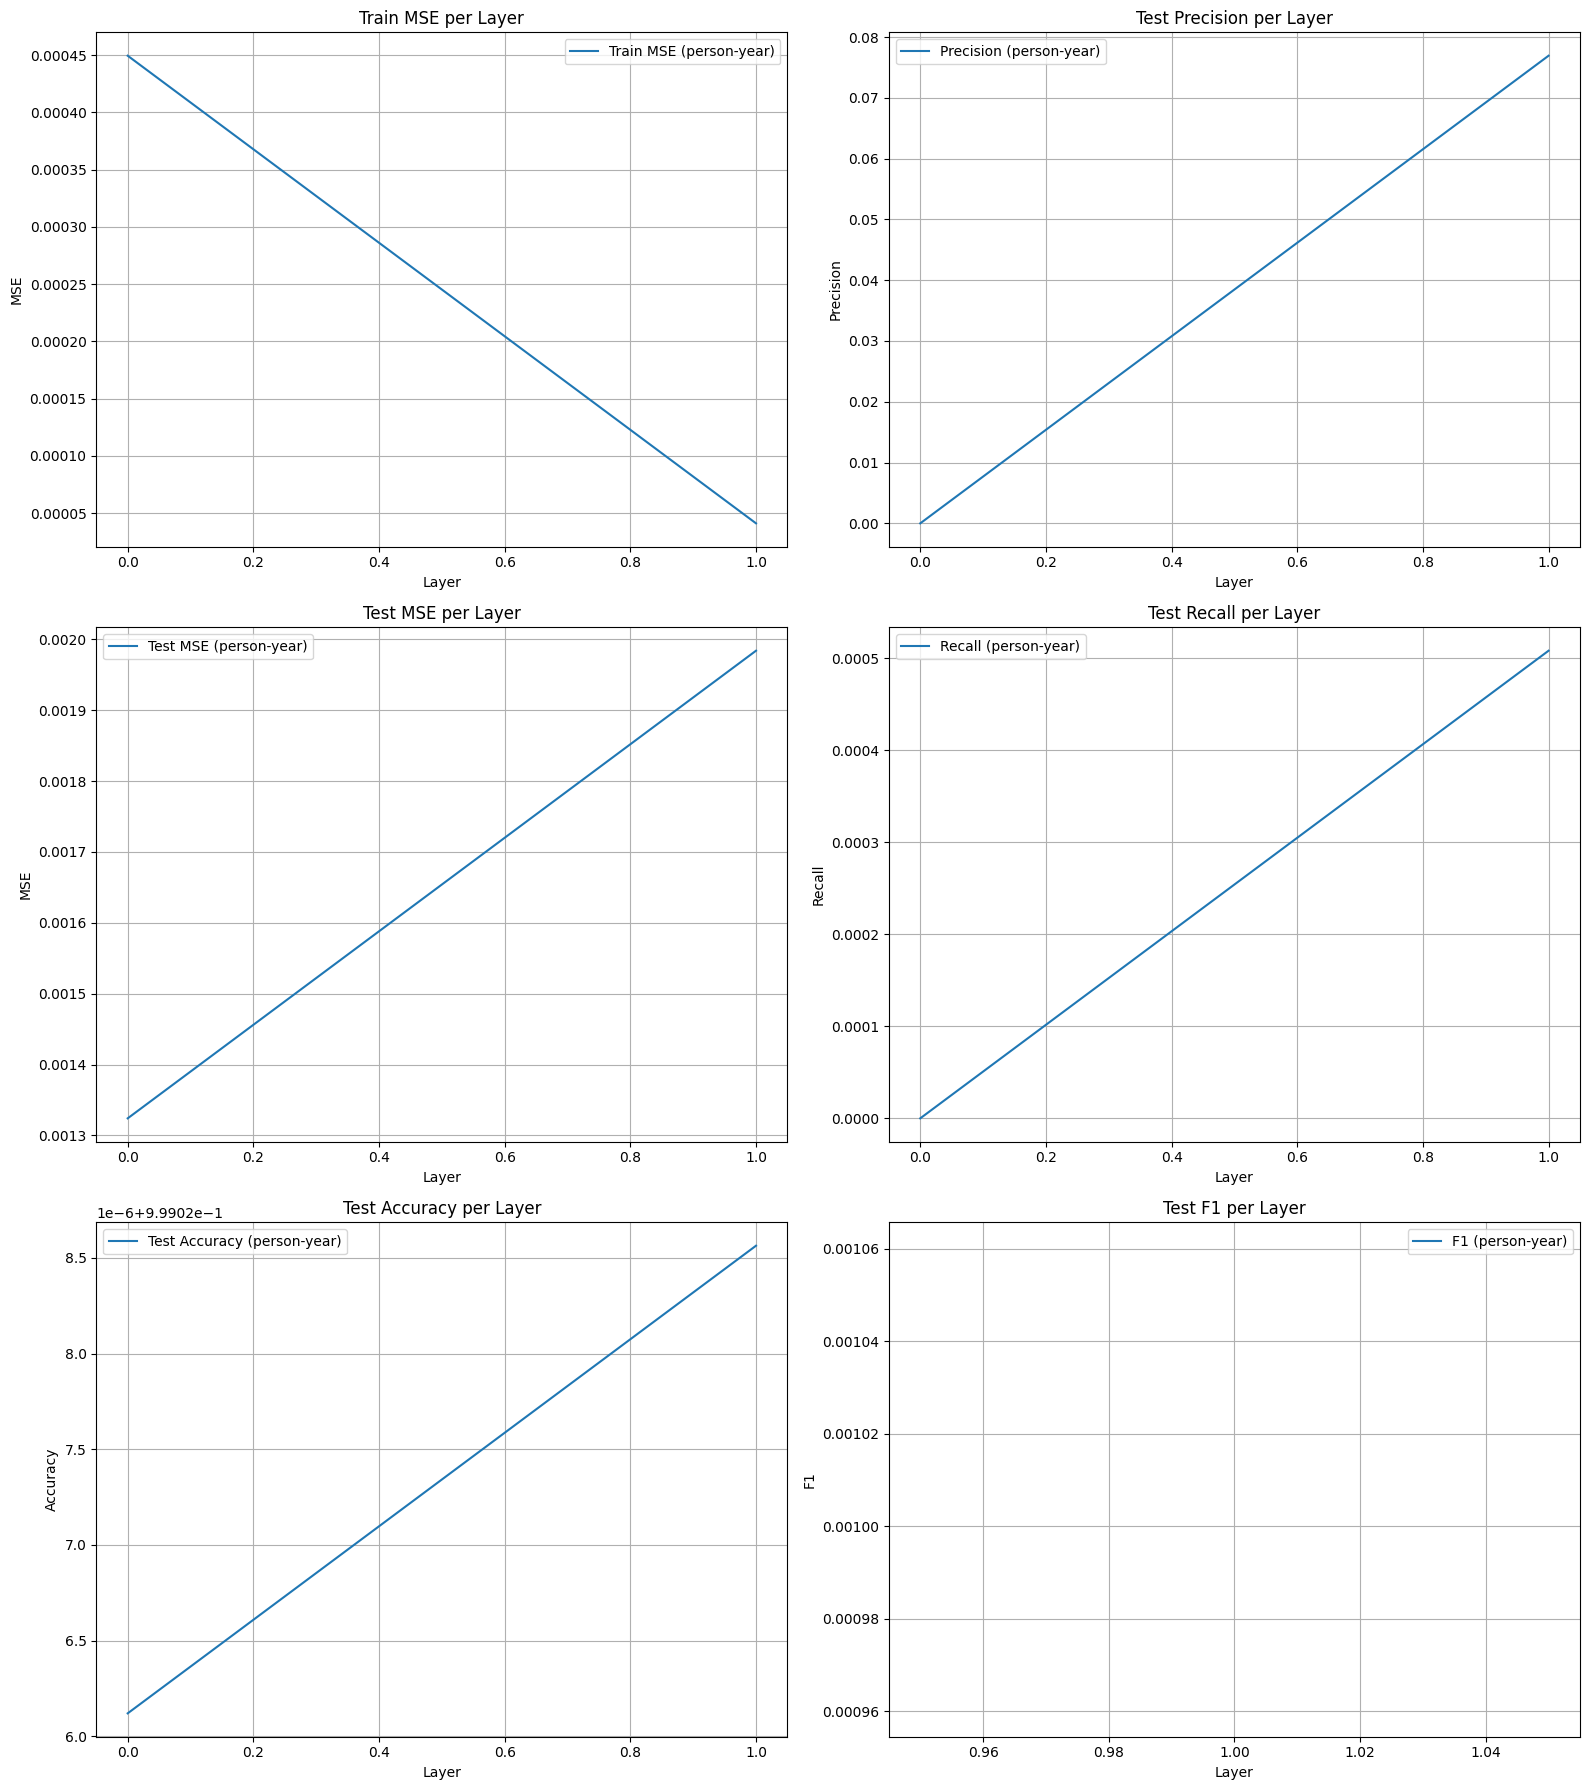

In [35]:
# Create a single figure with subplots including PRF metrics
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Left column: MSE and Accuracy
for rel, mse_values in train_mse.items():
    axes[0, 0].plot(range(len(mse_values)), mse_values, label=f"Train MSE ({rel})")
axes[0, 0].set_title('Train MSE per Layer')
axes[0, 0].set_xlabel('Layer')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid()

for rel, mse_values in test_mse.items():
    axes[1, 0].plot(range(len(mse_values)), mse_values, label=f"Test MSE ({rel})")
axes[1, 0].set_title('Test MSE per Layer')
axes[1, 0].set_xlabel('Layer')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].legend()
axes[1, 0].grid()

for rel, acc_values in test_acc.items():
    axes[2, 0].plot(range(len(acc_values)), acc_values, label=f"Test Accuracy ({rel})")
axes[2, 0].set_title('Test Accuracy per Layer')
axes[2, 0].set_xlabel('Layer')
axes[2, 0].set_ylabel('Accuracy')
axes[2, 0].legend()
axes[2, 0].grid()

# Right column: Precision, Recall, F1
for rel, vals in test_precision.items():
    axes[0, 1].plot(range(len(vals)), vals, label=f"Precision ({rel})")
axes[0, 1].set_title('Test Precision per Layer')
axes[0, 1].set_xlabel('Layer')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend()
axes[0, 1].grid()

for rel, vals in test_recall.items():
    axes[1, 1].plot(range(len(vals)), vals, label=f"Recall ({rel})")
axes[1, 1].set_title('Test Recall per Layer')
axes[1, 1].set_xlabel('Layer')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid()

for rel, vals in test_f1.items():
    axes[2, 1].plot(range(len(vals)), vals, label=f"F1 ({rel})")
axes[2, 1].set_title('Test F1 per Layer')
axes[2, 1].set_xlabel('Layer')
axes[2, 1].set_ylabel('F1')
axes[2, 1].legend()
axes[2, 1].grid()

# Adjust layout and show the figure
plt.tight_layout()
plt.show()

In [ ]:
# Plot PR-AUC (Average Precision) per Layer
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for rel, ap_values in test_pr_auc.items():
    ax.plot(range(len(ap_values)), ap_values, marker='o', label=f"PR-AUC ({rel})")
ax.set_title('Test PR-AUC (Average Precision) per Layer')
ax.set_xlabel('Layer')
ax.set_ylabel('PR-AUC')
ax.set_ylim(0.0, 1.05)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_acc

{'person-year': [0.9990261197090149, 0.9990285634994507]}

In [39]:
test_precision

{'person-year': [0.0, 0.07692307692307693]}

In [ ]:
# Plot Precision, Recall, and F1 per Layer
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for rel, vals in test_precision.items():
    axes[0].plot(range(len(vals)), vals, label=f"Precision ({rel})")
axes[0].set_title('Test Precision per Layer')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid()

for rel, vals in test_recall.items():
    axes[1].plot(range(len(vals)), vals, label=f"Recall ({rel})")
axes[1].set_title('Test Recall per Layer')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Recall')
axes[1].legend()
axes[1].grid()

for rel, vals in test_f1.items():
    axes[2].plot(range(len(vals)), vals, label=f"F1 ({rel})")
axes[2].set_title('Test F1 per Layer')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()